In [1]:
import sys
import os
import torch

# 1. Add the project folder to the system path so Python can see your 'src' folder
sys.path.append(os.getcwd())

# 2. Check if the GPU is active (Crucial for Lightning AI)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Using Device: {DEVICE}")

# 3. Create the checkpoints folder if it doesn't exist
os.makedirs("checkpoints", exist_ok=True)

✅ Using Device: cuda


In [4]:
# Import the train function from your existing src/train.py
from src.train import train

print("🚀 Starting Training Loop...")
print("Note: The first few minutes will be 'Parsing JSONs'. Please wait.")

# This triggers the exact logic you wrote in your train.py
try:
    train()
except Exception as e:
    print(f"❌ An error occurred: {e}")
    print("Check if your dataset is in 'imdb/json' and 'imdb/dataset'")

🚀 Starting Training Loop...
Note: The first few minutes will be 'Parsing JSONs'. Please wait.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 Complete. Loss: 0.2476
Epoch 2 Complete. Loss: 0.1482
Epoch 3 Complete. Loss: 0.2216
Epoch 4 Complete. Loss: 0.1259
Epoch 5 Complete. Loss: 0.0905
Epoch 6 Complete. Loss: 0.0865
Epoch 7 Complete. Loss: 0.1061
Epoch 8 Complete. Loss: 0.0750
Epoch 9 Complete. Loss: 0.0372
Epoch 10 Complete. Loss: 0.0599


In [9]:
from src.model import MultiModalModel
# ADD 'parse_json_to_dataframe' to this line:
from src.data_loader import MovieGenreDataset, ALL_GENRES, parse_json_to_dataframe 
from torch.utils.data import DataLoader
from torchvision import transforms
from transformers import DistilBertTokenizer
from sklearn.model_selection import train_test_split # Needed for the split line
import torch

# 1. Initialize a fresh model architecture
model = MultiModalModel(num_genres=len(ALL_GENRES)).to(DEVICE)

# 2. Load the weights you just trained (Epoch 10)
checkpoint_path = "checkpoints/model_epoch_10.pt"
model.load_state_dict(torch.load(checkpoint_path))
model.eval() 
print("✅ Trained weights loaded successfully!")

# 3. Re-prepare the validation loader
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

# Now this line will work because the function is imported
df = parse_json_to_dataframe("imdb/json", "imdb/dataset") 
_, val_df = train_test_split(df, test_size=0.15, random_state=42)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_loader = DataLoader(MovieGenreDataset(val_df, tokenizer, transform), batch_size=16)
print("✅ Validation data ready.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Trained weights loaded successfully!
✅ Validation data ready.


In [10]:
from sklearn.metrics import classification_report, f1_score
import numpy as np

all_preds = []
all_labels = []

print("⏳ Calculating metrics...")
with torch.no_grad():
    for images, ids, mask, labels in val_loader:
        images, ids, mask, labels = images.to(DEVICE), ids.to(DEVICE), mask.to(DEVICE), labels.to(DEVICE)
        outputs = model(images, ids, mask)
        
        # Binary prediction (0 or 1) based on 0.5 threshold
        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.cpu().numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

# Calculate Macro-F1 (The standard for MM-IMDb)
macro_f1 = f1_score(all_labels, all_preds, average='macro')
print(f"\n🚀 Final Macro-F1 Score: {macro_f1:.4f}")

# Show detailed report
print("\n--- Detailed Genre Analysis ---")
print(classification_report(all_labels, all_preds, target_names=ALL_GENRES, zero_division=0))

⏳ Calculating metrics...

🚀 Final Macro-F1 Score: 0.8410

--- Detailed Genre Analysis ---
              precision    recall  f1-score   support

      Action       0.93      0.93      0.93      1031
   Adventure       0.90      0.93      0.91       784
   Animation       0.97      0.95      0.96       409
   Biography       0.95      0.90      0.92       439
      Comedy       0.95      0.94      0.94      1417
       Crime       0.92      0.91      0.91       660
 Documentary       0.94      0.91      0.92       141
       Drama       0.95      0.95      0.95      2332
      Family       0.93      0.89      0.91       407
     Fantasy       0.95      0.86      0.90       386
   Film-Noir       0.96      0.62      0.75        37
     History       0.90      0.93      0.91       375
      Horror       0.98      0.92      0.95       610
       Music       0.93      0.90      0.91       345
     Musical       0.95      0.85      0.90       294
     Mystery       0.93      0.82      0.87  

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [12]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 126.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 182.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 203.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


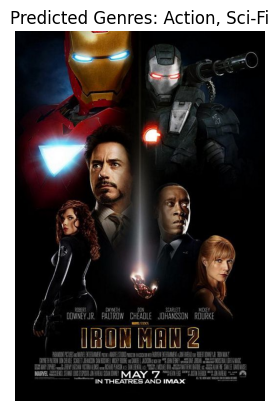

Action: 99.52%
Sci-Fi: 98.45%


In [13]:
import torch
import requests
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

def predict_movie_genre(image_path_or_url, plot_text, model, tokenizer, device, genres_list):
    # 1. Load and Preprocess Image
    if image_path_or_url.startswith('http'):
        img = Image.open(requests.get(image_path_or_url, stream=True).raw).convert('RGB')
    else:
        img = Image.open(image_path_or_url).convert('RGB')
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    img_tensor = transform(img).unsqueeze(0).to(device)

    # 2. Preprocess Text
    encoding = tokenizer(
        plot_text,
        max_length=256,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    ).to(device)

    # 3. Inference
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor, encoding['input_ids'], encoding['attention_mask'])
        # Use sigmoid because it's multi-label
        probs = torch.sigmoid(outputs).cpu().numpy()[0]
    
    # 4. Get results (Threshold at 0.5)
    results = {genres_list[i]: probs[i] for i in range(len(genres_list)) if probs[i] > 0.5}
    # Sort by highest probability
    sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)

    # 5. Visualize
    plt.imshow(img)
    plt.title(f"Predicted Genres: {', '.join([r[0] for r in sorted_results])}")
    plt.axis('off')
    plt.show()
    
    for genre, prob in sorted_results:
        print(f"{genre}: {prob*100:.2f}%")

# --- TEST IT HERE ---
# Find a new movie on Google/IMDb and paste the details below
test_image = "https://images-na.ssl-images-amazon.com/images/M/MV5BMTM0MDgwNjMyMl5BMl5BanBnXkFtZTcwNTg3NzAzMw@@._V1_.jpg" # Example: Iron Man
test_plot = "After being held captive in an Afghan cave, billionaire engineer Tony Stark creates a unique weaponized suit of armor to fight evil."

predict_movie_genre(test_image, test_plot, model, tokenizer, DEVICE, ALL_GENRES)